
# House Prices - Advanced Regression Techniques

## Storytelling do Projeto

### Problema de Negócio
O mercado imobiliário depende de estimativas precisas para definir preços de venda. O objetivo deste projeto é identificar os fatores que mais influenciam o valor de uma residência e desenvolver modelos capazes de prever seu preço.

### Dataset
- Registros: **1460**
- Variáveis: **81**
- Variável alvo: **SalePrice**
- Preço médio: **US$ 180,921.20**
- Preço mediano: **US$ 163,000.00**



## Bibliotecas


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor


In [2]:

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)
train.head()


(1460, 81)
(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Análise Exploratória de Dados

In [15]:

train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:

train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:

missing = train.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(20)


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

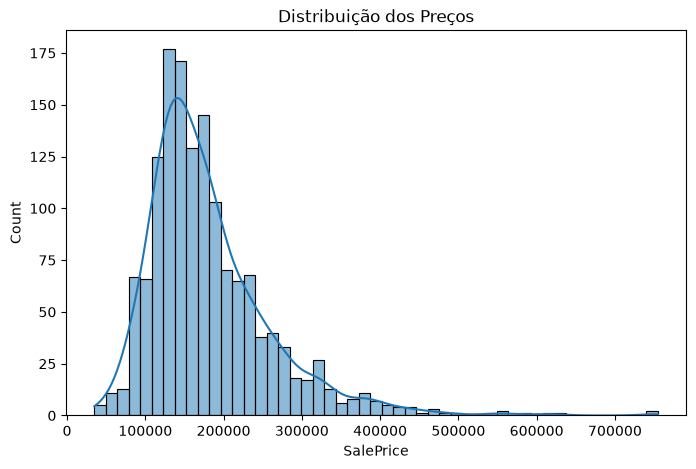

In [6]:

plt.figure(figsize=(8,5))
sns.histplot(train['SalePrice'], kde=True)
plt.title('Distribuição dos Preços')
plt.show()


In [7]:

top_corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_corr.head(15)


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


### Principais Insights

- Casas com maior qualidade geral tendem a possuir preços maiores.
- Área habitável possui forte relação com o valor de venda.
- Garagens maiores e porões maiores também influenciam positivamente o preço.
- Existem diversos valores ausentes que precisam ser tratados.


## 2. Feature Engineering

In [8]:

df = train.copy()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Missing')
    else:
        df[col] = df[col].fillna(df[col].median())

df['TotalArea'] = (
    df['TotalBsmtSF'] +
    df['1stFlrSF'] +
    df['2ndFlrSF']
)

df = pd.get_dummies(df, drop_first=True)

print(df.shape)


(1460, 263)


## 3. Aprendizagem Supervisionada - Regressão Linear

In [9]:

X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

r2 = r2_score(y_test,pred)
mae = mean_absolute_error(y_test,pred)
rmse = np.sqrt(mean_squared_error(y_test,pred))

print('R²:', r2)
print('MAE:', mae)
print('RMSE:', rmse)


R²: 0.855621196926319
MAE: 20294.021349760496
RMSE: 33278.10867489865



### Interpretação

- **R²** mede quanto da variação do preço é explicada pelo modelo.
- **MAE** representa o erro médio absoluto.
- **RMSE** penaliza erros maiores.


## 4. Aprendizagem Supervisionada - Classificação

In [10]:

base = df.copy()

mediana = base['SalePrice'].median()

base['PrecoAlto'] = (
    base['SalePrice'] > mediana
).astype(int)

X = base.drop(['SalePrice','PrecoAlto'], axis=1)
y = base['PrecoAlto']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(random_state=42)

clf.fit(X_train,y_train)

pred = clf.predict(X_test)

print('Accuracy:',accuracy_score(y_test,pred))
print('Precision:',precision_score(y_test,pred))
print('Recall:',recall_score(y_test,pred))
print('F1:',f1_score(y_test,pred))


Accuracy: 0.952054794520548
Precision: 0.9333333333333333
Recall: 0.9618320610687023
F1: 0.9473684210526315


## 5. Clusterização (K-Means)

C:\Users\kluiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


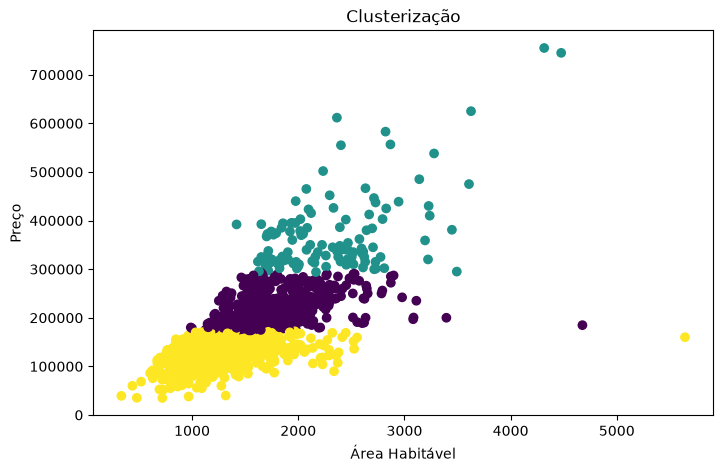

In [11]:

dados = df[['GrLivArea','SalePrice']]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(dados)

plt.figure(figsize=(8,5))
plt.scatter(
    dados['GrLivArea'],
    dados['SalePrice'],
    c=clusters
)
plt.xlabel('Área Habitável')
plt.ylabel('Preço')
plt.title('Clusterização')
plt.show()



### Interpretação dos Clusters

- Cluster 1: imóveis de menor valor.
- Cluster 2: imóveis intermediários.
- Cluster 3: imóveis premium.


## 6. Redução de Dimensionalidade (PCA)

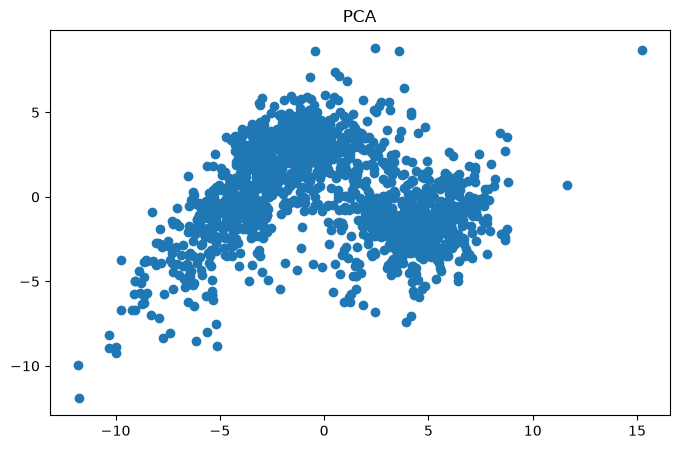

Variância Explicada: 0.0984118591917862


In [12]:

X = df.drop('SalePrice', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

resultado = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(resultado[:,0], resultado[:,1])
plt.title('PCA')
plt.show()

print('Variância Explicada:', pca.explained_variance_ratio_.sum())


## 7. Detecção de Outliers (LOF)

In [13]:

lof_data = df[['GrLivArea','SalePrice']]

lof = LocalOutlierFactor()

outlier = lof.fit_predict(lof_data)

print(pd.Series(outlier).value_counts())


 1    1431
-1      29
Name: count, dtype: int64


## 8. Análise de Associação (Apriori)

In [14]:

from mlxtend.frequent_patterns import apriori, association_rules

assoc = train[['OverallQual','GarageCars']].copy()

assoc['AltaQualidade'] = assoc['OverallQual'] >= 7
assoc['GaragemGrande'] = assoc['GarageCars'] >= 2

basket = assoc[['AltaQualidade','GaragemGrande']]

freq = apriori(
    basket.astype(bool),
    min_support=0.1,
    use_colnames=True
)

rules = association_rules(
    freq,
    metric='confidence',
    min_threshold=0.5
)

rules[['antecedents','consequents','support','confidence','lift']]


,antecedents,consequents,support,confidence,lift
0,(AltaQualidade),(GaragemGrande),0.359589,0.958029,1.384874
1,(GaragemGrande),(AltaQualidade),0.359589,0.519802,1.384874



# Conclusão Final

O projeto demonstrou que características estruturais, principalmente qualidade geral, área habitável e tamanho da garagem, possuem forte influência sobre o preço dos imóveis.

Os modelos supervisionados permitiram prever preços e classificar imóveis de alto valor. Já as técnicas não supervisionadas ajudaram a identificar padrões, grupos de imóveis semelhantes e possíveis outliers.

Dessa forma, foi possível aplicar conceitos de análise exploratória, feature engineering, regressão, classificação, clusterização, redução de dimensionalidade, associação e detecção de anomalias em um problema real de mercado imobiliário.
